In [2]:
# Imports and Setup
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')  # Use Agg backend for matplotlib
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # Fallback if only plt is imported

get_ipython().run_line_magic('matplotlib', 'inline')

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder

# Display settings
pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv("/kaggle/input/datasets/sonalshinde123/ai-driven-resume-screening-dataset/ai_resume_screening.csv")

# Quick display of the first few rows
print('Data Loaded Successfully. Here are the first few rows:')
df.head()

Data Loaded Successfully. Here are the first few rows:


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [8]:
# Data Exploration
# Let's quickly inspect the data to identify data types, missing values, and get summary statistics.
print('Dataset Information:')
df.info()

print('\nSummary Statistics:')
df.describe()

# Check for missing values in the dataset
print('\nMissing Values in each column:')
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   years_experience    30000 non-null  int64  
 1   skills_match_score  30000 non-null  float64
 2   education_level     30000 non-null  object 
 3   project_count       30000 non-null  int64  
 4   resume_length       30000 non-null  int64  
 5   github_activity     30000 non-null  int64  
 6   shortlisted         30000 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 1.6+ MB

Summary Statistics:

Missing Values in each column:
years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64


In [9]:
# Data Cleaning and Preprocessing
# In this section, we will handle any missing values and encode categorical variables

# Verify if there are missing values in critical columns
if df.isnull().sum().any():
    # Fill missing numeric values with the median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'Filled missing values in numeric column {col} with median {median_val}')

    # Fill missing categorical values with the mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f'Filled missing values in categorical column {col} with mode {mode_val}')
else:
    print('No missing values found in the dataset.')

# Convert 'shortlisted' to a binary numeric variable for prediction
# Assuming 'Yes' and 'No' values in the 'shortlisted' column
df['shortlisted_binary'] = df['shortlisted'].apply(lambda x: 1 if x.lower() == 'yes' else 0)

# Encode 'education_level' using label encoding
le = LabelEncoder()
df['education_level_encoded'] = le.fit_transform(df['education_level'])

# Display a sample of the preprocessed dataframe
df.head()

No missing values found in the dataset.


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted,shortlisted_binary,education_level_encoded
0,6,84.7,Bachelors,7,234,158,No,0,0
1,3,59.1,Masters,5,502,77,No,0,2
2,12,100.0,Masters,12,753,381,Yes,1,2
3,14,66.8,High School,8,529,407,Yes,1,1
4,10,99.6,Bachelors,10,754,331,Yes,1,0



TRAINING LOGISTIC REGRESSION...

Logistic Regression Evaluation
Accuracy  : 0.9038
Precision : 0.9274
Recall    : 0.9356
F1 Score  : 0.9315
ROC AUC   : 0.9618

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1807
           1       0.93      0.94      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.89      0.88      0.89      6000
weighted avg       0.90      0.90      0.90      6000



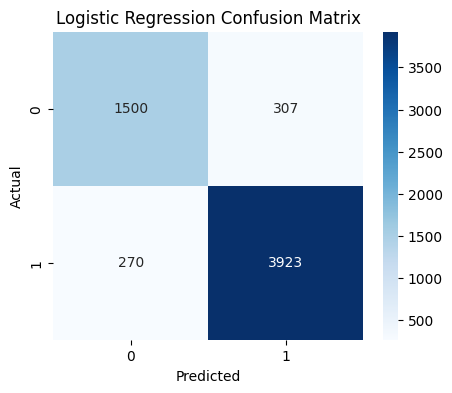

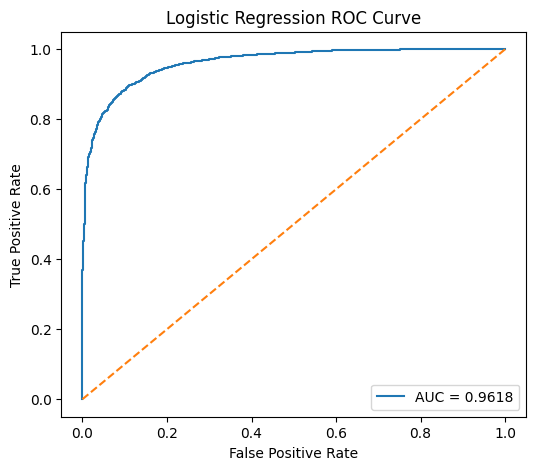


TRAINING RANDOM FOREST...

Random Forest Evaluation
Accuracy  : 0.9032
Precision : 0.9249
Recall    : 0.9375
F1 Score  : 0.9312
ROC AUC   : 0.9634

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.82      0.84      1807
           1       0.92      0.94      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.89      0.88      0.88      6000
weighted avg       0.90      0.90      0.90      6000



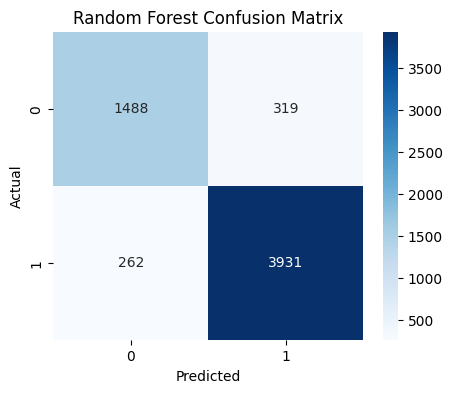

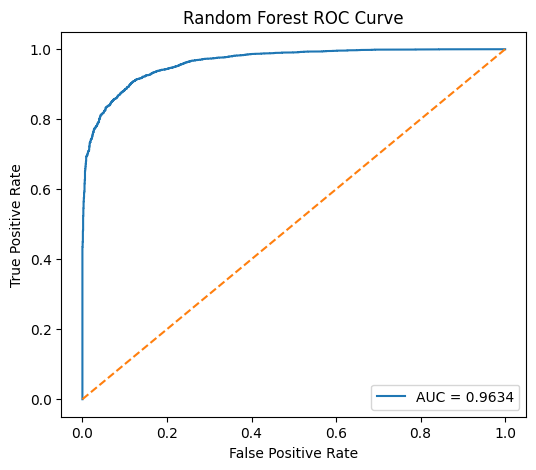


Feature Importance:
                    Feature  Importance
6  candidate_strength_index    0.342183
0          years_experience    0.232858
4           github_activity    0.129604
2             project_count    0.106912
8      resume_quality_score    0.062023
1        skills_match_score    0.040915
3             resume_length    0.037766
7     experience_efficiency    0.025558
5   education_level_encoded    0.022181


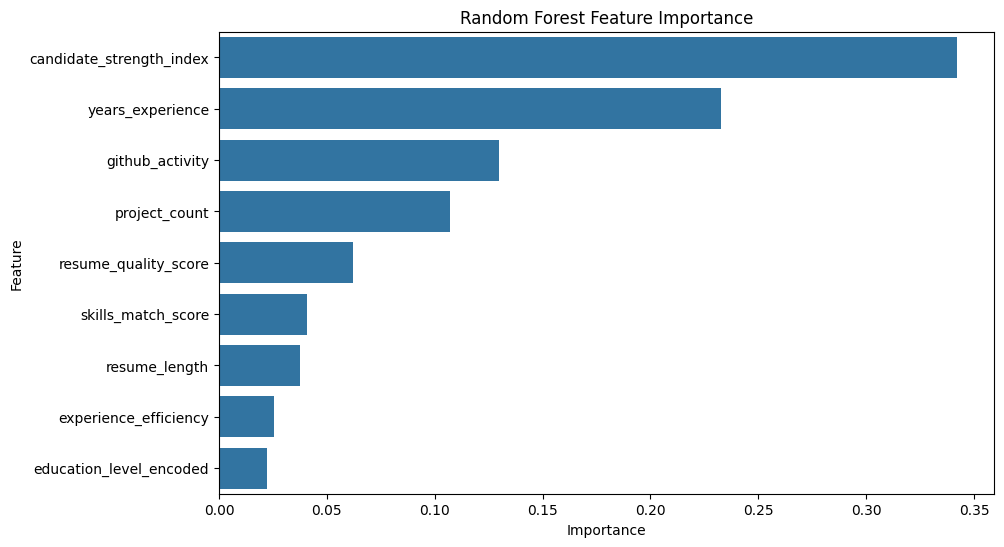


TRAINING SVM...

Support Vector Machine Evaluation
Accuracy  : 0.9058
Precision : 0.9250
Recall    : 0.9416
F1 Score  : 0.9332
ROC AUC   : 0.9486

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1807
           1       0.93      0.94      0.93      4193

    accuracy                           0.91      6000
   macro avg       0.89      0.88      0.89      6000
weighted avg       0.91      0.91      0.91      6000



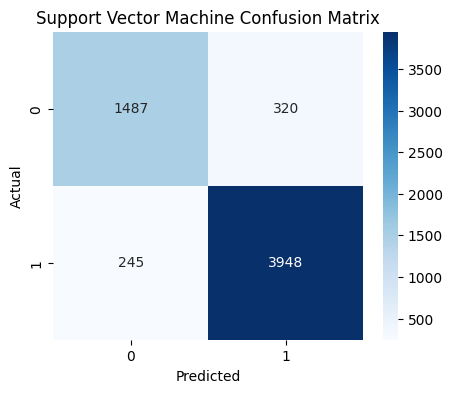

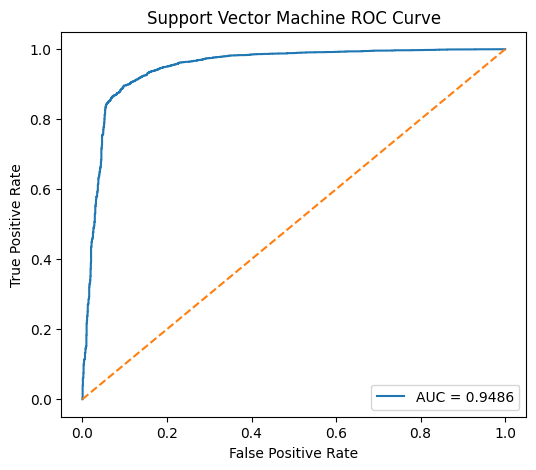


TRAINING KNN...

K-Nearest Neighbors Evaluation
Accuracy  : 0.8965
Precision : 0.9224
Recall    : 0.9301
F1 Score  : 0.9263
ROC AUC   : 0.9363

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.82      0.83      1807
           1       0.92      0.93      0.93      4193

    accuracy                           0.90      6000
   macro avg       0.88      0.87      0.88      6000
weighted avg       0.90      0.90      0.90      6000



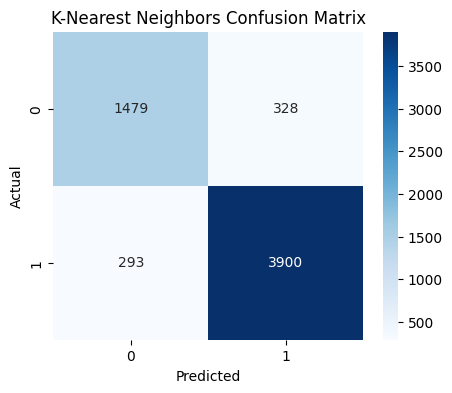

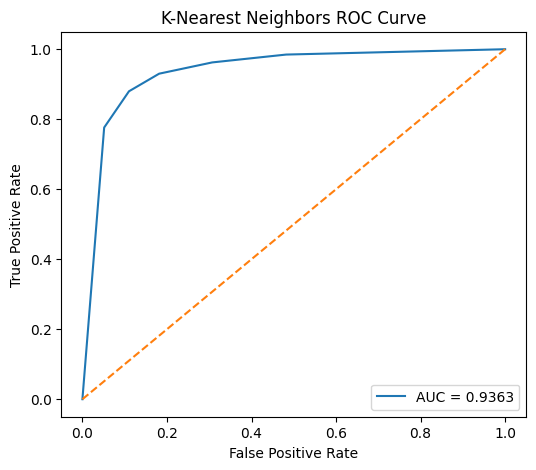


TRAINING XGBOOST...

XGBoost Evaluation
Accuracy  : 0.9063
Precision : 0.9289
Recall    : 0.9378
F1 Score  : 0.9333
ROC AUC   : 0.9659

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1807
           1       0.93      0.94      0.93      4193

    accuracy                           0.91      6000
   macro avg       0.89      0.89      0.89      6000
weighted avg       0.91      0.91      0.91      6000



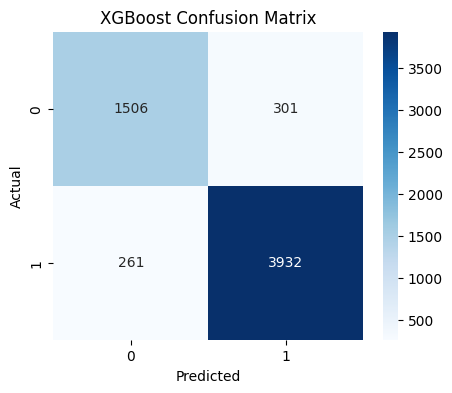

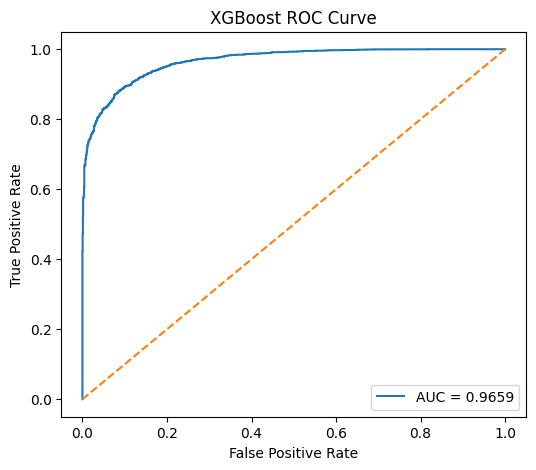


FINAL MODEL COMPARISON
                 Model  Accuracy  F1 Score   ROC AUC
0  Logistic Regression  0.903833  0.931497  0.961790
1        Random Forest  0.903167  0.931186  0.963439
2                  SVM  0.905833  0.933223  0.948580
3                  KNN  0.896500  0.926256  0.936300
4              XGBoost  0.906333  0.933302  0.965947

BEST MODEL:
Model        XGBoost
Accuracy    0.906333
F1 Score    0.933302
ROC AUC     0.965947
Name: 4, dtype: object

Model and scaler saved successfully.


In [10]:
# ============================================================
# AI RESUME SCREENING SYSTEM
# Multiple ML Models with Separate Evaluation Pipelines
# Novel Contributions Included
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# ============================================================
# LOAD DATASET
# ============================================================

# Example:
# df = pd.read_csv("resume_screening.csv")

# ============================================================
# FEATURE ENGINEERING (NOVEL CONTRIBUTIONS)
# ============================================================

# ------------------------------
# Novel Feature 1:
# Candidate Strength Index (CSI)
# Combines skills, projects, github activity
# ------------------------------

df['candidate_strength_index'] = (
    (df['skills_match_score'] * 0.5) +
    (df['project_count'] * 2) +
    (df['github_activity'] * 0.05)
)

# ------------------------------
# Novel Feature 2:
# Experience Efficiency Score
# Measures productivity relative to experience
# ------------------------------

df['experience_efficiency'] = (
    df['project_count'] / (df['years_experience'] + 1)
)

# ------------------------------
# Novel Feature 3:
# Resume Quality Score
# Resume length + skills score combination
# ------------------------------

df['resume_quality_score'] = (
    df['resume_length'] * 0.2 +
    df['skills_match_score'] * 0.8
)

# ============================================================
# FEATURES & TARGET
# ============================================================

X = df.drop(columns=[
    'shortlisted',
    'shortlisted_binary',
    'education_level'
])

y = df['shortlisted_binary']

# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# EVALUATION FUNCTION
# ============================================================

def evaluate_model(model_name, y_test, y_pred, y_prob):

    print("\n" + "="*60)
    print(f"{model_name} Evaluation")
    print("="*60)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC AUC   : {roc_auc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{model_name} Confusion Matrix')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0,1], [0,1], linestyle='--')
    plt.title(f'{model_name} ROC Curve')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


# ============================================================
# MODEL 1 — LOGISTIC REGRESSION
# ============================================================

print("\nTRAINING LOGISTIC REGRESSION...")

lr_model = LogisticRegression()

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

# ============================================================
# MODEL 2 — RANDOM FOREST
# ============================================================

print("\nTRAINING RANDOM FOREST...")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

# ============================================================
# FEATURE IMPORTANCE (NOVEL ANALYSIS)
# ============================================================

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance:")
print(importance_df)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Random Forest Feature Importance")
plt.show()

# ============================================================
# MODEL 3 — SUPPORT VECTOR MACHINE (SVM)
# ============================================================

print("\nTRAINING SVM...")

svm_model = SVC(
    kernel='rbf',
    probability=True
)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)
svm_prob = svm_model.predict_proba(X_test_scaled)[:,1]

evaluate_model(
    "Support Vector Machine",
    y_test,
    svm_pred,
    svm_prob
)

# ============================================================
# MODEL 4 — K-NEAREST NEIGHBORS (KNN)
# ============================================================

print("\nTRAINING KNN...")

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:,1]

evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_pred,
    knn_prob
)

# ============================================================
# MODEL 5 — XGBOOST (ADVANCED MODEL)
# ============================================================

print("\nTRAINING XGBOOST...")

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:,1]

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'SVM',
        'KNN',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred),
        f1_score(y_test, knn_pred),
        f1_score(y_test, xgb_pred)
    ],
    'ROC AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, svm_prob),
        roc_auc_score(y_test, knn_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

print("\nFINAL MODEL COMPARISON")
print(results)

# ============================================================
# BEST MODEL SELECTION
# ============================================================

best_model = results.sort_values(
    by='ROC AUC',
    ascending=False
).iloc[0]

print("\nBEST MODEL:")
print(best_model)

# ============================================================
# SAVE BEST MODEL (OPTIONAL)
# ============================================================

import joblib

joblib.dump(xgb_model, 'best_resume_screening_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("\nModel and scaler saved successfully.")